Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC2017 - Modelación y Simulación

Cristian Túnchez (231359)  
Daniel Chet (231177)

# Laboratorio 4: Modelo ABM de Movilidad Urbana

Este notebook desarrolla el **Task 1** y **Task 2** del laboratorio. Construye un modelo basado en agentes (ABM) en Mesa que simula el desplazamiento diario en un centro urbano de 20×20 celdas y compara estadísticamente la congestión con y sin una política de bicicletas compartidas.

**Preparación de Entorno**

In [ ]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import mesa
from mesa.time import RandomActivation
from mesa.space import MultiGrid

warnings.filterwarnings("ignore", category=DeprecationWarning)

GRID = 20             # lado de la cuadricula: 20 x 20 = 400 celdas
N = 150               # conmutadores por corrida
T = 10                # pasos de simulacion
UMBRAL_BICI = 3.0     # km: distancia maxima para usar bicicleta

MU = np.array([8500.0, 6.5])                              # [ingreso (Q), distancia (km)]
SIGMA = np.array([[4_000_000.0, -800.0], [-800.0, 4.0]])  # matriz de covarianza

print("Mesa", mesa.__version__)

Could not import SolaraViz. If you need it, install with 'pip install --pre mesa[viz]'


Mesa 3.0.3


## Task 1.1 — Agentes con atributos correlacionados

Cada `CommutterAgent` tiene dos atributos que no son independientes: ingreso mensual y distancia al trabajo. La covarianza es negativa, así que quien gana más tiende a vivir más cerca.

Para generar pares correlacionados se usa la **descomposición de Cholesky**: se factoriza $\Sigma = L L^{\top}$, se sortean normales estándar independientes $Z$ y se transforman con $X = \mu + Z L^{\top}$.

In [2]:
def muestrear_atributos(n, rng):
    """Genera n pares (ingreso, distancia) desde la normal multivariada por Cholesky."""
    L = np.linalg.cholesky(SIGMA)      # SIGMA = L @ L.T
    Z = rng.standard_normal((n, 2))    # normales estandar independientes
    return MU + Z @ L.T                # la correlacion la induce L


rng_demo = np.random.default_rng(42)
atributos = muestrear_atributos(N, rng_demo)
ingreso, distancia = atributos[:, 0], atributos[:, 1]

corr_muestral = np.corrcoef(ingreso, distancia)[0, 1]
corr_teorica = SIGMA[0, 1] / np.sqrt(SIGMA[0, 0] * SIGMA[1, 1])

print(f"correlacion muestral: {corr_muestral:.3f}")
print(f"correlacion teorica : {corr_teorica:.3f}")

correlacion muestral: -0.139
correlacion teorica : -0.200


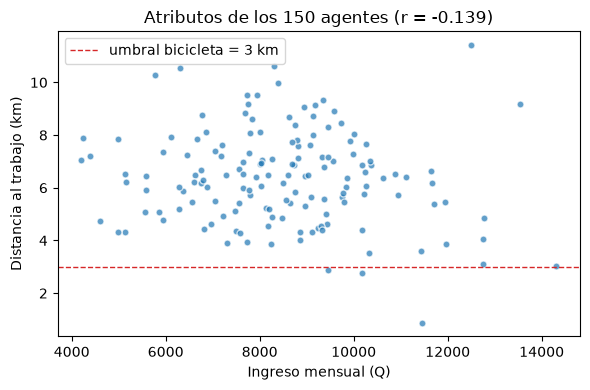

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(ingreso, distancia, s=25, alpha=0.7, color="tab:blue", edgecolor="white")
ax.axhline(UMBRAL_BICI, color="tab:red", linestyle="--", linewidth=1,
           label=f"umbral bicicleta = {UMBRAL_BICI:.0f} km")
ax.set_xlabel("Ingreso mensual (Q)")
ax.set_ylabel("Distancia al trabajo (km)")
ax.set_title(f"Atributos de los {N} agentes (r = {corr_muestral:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

La correlación muestral es **negativa** (−0.139), del mismo signo que la covarianza especificada, y la nube muestra una tendencia descendente leve.

### Regla de transporte

$$\text{modo}_i = \begin{cases}\text{bicicleta} & \text{si } \text{distancia}_i \le 3 \text{ km y la política está activa}\\ \text{automóvil} & \text{en otro caso}\end{cases}$$

Las dos clases de agente se definen abajo. `choose_transport` implementa la regla y `step` implementa
la movilidad del Task 1.2.

In [ ]:
class VehicleAgent(mesa.Agent):
    """Vehiculo en circulacion. No tiene logica propia: lo mueve su conmutador."""


class CommutterAgent(mesa.Agent):
    """Persona que se desplaza de su origen a su destino en la cuadricula."""

    def __init__(self, model, ingreso, distancia, destino):
        super().__init__(model)
        self.ingreso = ingreso        # quetzales al mes
        self.distancia = distancia    # km al trabajo
        self.destino = destino        # celda (x, y) de llegada
        self.modo = self.choose_transport()
        self.vehiculo = None          # VehicleAgent emparejado, si viaja en auto

    def choose_transport(self):
        """Regla determinista de eleccion de modo."""
        if self.distancia <= UMBRAL_BICI and self.model.policy_active:
            return "bicicleta"
        return "automovil"

    def step(self):
        self.model.orden_activacion.append(self.unique_id)  # evidencia para el Task 1.3

        # Un paso del camino de Manhattan más corto (primero el eje x, luego el eje y).
        x, y = self.pos
        dx, dy = self.destino
        if x != dx:
            objetivo = (x + (1 if dx > x else -1), y)
        elif y != dy:
            objetivo = (x, y + (1 if dy > y else -1))
        else:
            objetivo = self.pos

        # Si otro conmutador ya ocupa la celda objetivo, el agente espera donde esta.
        ocupada = any(isinstance(a, CommutterAgent)
                      for a in self.model.grid.get_cell_list_contents([objetivo]))
        if objetivo != self.pos and not ocupada:
            self.model.grid.move_agent(self, objetivo)
            if self.vehiculo is not None:
                self.model.grid.move_agent(self.vehiculo, objetivo)

        # Condicion terminal: llego a su destino y sale del sistema.
        if self.pos == self.destino:
            if self.vehiculo is not None:
                self.model.grid.remove_agent(self.vehiculo)
                self.model.vehiculos.remove(self.vehiculo)
            self.model.schedule.remove(self)
            self.model.grid.remove_agent(self)

**¿Por qué la regla es determinista?**

El modo queda completamente fijado por la distancia del agente y por el valor de la política; dos agentes con la misma distancia siempre eligen lo mismo, y una misma corrida repetida con la misma semilla produce las mismas elecciones. No interviene ningún sorteo dentro de la regla. La aleatoriedad del modelo está en el muestreo inicial de atributos, no en la decisión.

**¿Cómo volverla estocástica?**

Bastaría con reemplazar el umbral establecido por una probabilidad de usar bicicleta que decrezca con la distancia, por ejemplo $p_i = 1 / (1 + e^{\,\beta(\text{distancia}_i - 3)})$, y sortear el modo con esa probabilidad. Así un agente que vive a 2.9 km no siempre usa bicicleta y uno a 3.1 km a veces sí, lo que captura la heterogeneidad en la disposición individual a pedalear.

### Modo de scheduling

Se usa **`RandomActivation`** (asíncrono aleatorio). El proceso real que se modela es el desplazamiento matutino de personas, cada quien sale de su casa a una hora distinta y avanza sin esperar a que los demás avancen. No existe un reloj que sincronice a la ciudad. Además, cuando dos personas compiten por el mismo espacio de calle, una pasa primero y la otra espera. Un esquema síncrono supondría que todos deciden y se mueven en el mismo instante, lo que corresponde a procesos físicos simultáneos y no a comportamiento social. Reordenar los agentes en cada paso evita además que un mismo agente tenga siempre la prioridad de paso.

## Task 1.2 — Movilidad, entorno y eliminación

El modelo une todo:

1. **Movilidad**: ya está en `CommutterAgent.step`. El agente avanza una celda por paso hacia su destino y espera si la celda objetivo está ocupada por otro conmutador.
2. **`congestion_map`**: arreglo NumPy de 20×20 que se recalcula al final de cada paso contando vehículos por celda. Es la variable de entorno del modelo, cualquier agente puede leerla para percibir la congestión sin comunicarse directamente con otro agente.
3. **Eliminación**: al llegar a su destino, el conmutador sale del schedule y de la cuadrícula.

In [5]:
class CityModel(mesa.Model):
    """Centro urbano de 20x20 celdas con conmutadores y vehiculos."""

    def __init__(self, policy_active=False, seed=None):
        super().__init__(seed=seed)
        self.policy_active = policy_active
        self.grid = MultiGrid(GRID, GRID, torus=False)
        self.schedule = RandomActivation(self)
        self.congestion_map = np.zeros((GRID, GRID), dtype=int)  # variable de entorno
        self.vehiculos = []
        self.orden_activacion = []

        rng = np.random.default_rng(seed)
        for ingreso, distancia in muestrear_atributos(N, rng):
            origen = tuple(int(v) for v in rng.integers(0, GRID, size=2))
            destino = tuple(int(v) for v in rng.integers(0, GRID, size=2))

            agente = CommutterAgent(self, float(ingreso), float(distancia), destino)
            self.grid.place_agent(agente, origen)
            self.schedule.add(agente)

            if agente.modo == "automovil":          # un vehiculo por conmutador en auto
                vehiculo = VehicleAgent(self)
                self.grid.place_agent(vehiculo, origen)
                agente.vehiculo = vehiculo
                self.vehiculos.append(vehiculo)

        self.actualizar_congestion()

    def actualizar_congestion(self):
        """Congestion de una celda = numero de VehicleAgent presentes en ella."""
        self.congestion_map[:] = 0
        for vehiculo in self.vehiculos:
            x, y = vehiculo.pos
            self.congestion_map[x, y] += 1

    def step(self):
        self.orden_activacion = []
        self.schedule.step()
        self.actualizar_congestion()

**¿Qué pasaría si se omitiera la eliminación?**

Los agentes que ya llegaron seguirían en la cuadrícula y sus vehículos seguirían contándose en `congestion_map`. La congestión medida al final nunca bajaría y el índice $Y$ quedaría fijo en 150 vehículos repartidos en 400 celdas, sin importar la política ni el tiempo simulado. El modelo sobrestimaría la congestión, perdería casi toda su variabilidad entre corridas y la comparación entre escenarios dejaría de tener sentido (los ciclistas también estarían "estacionados" para siempre en la vía). Además, los agentes ya llegados seguirían bloqueando celdas y estorbando a quienes aún viajan.

## Task 1.3 — Verificación de la implementación

Tres pruebas antes de correr el análisis estadístico.

In [6]:
# Prueba 1: scheduler
modelo = CityModel(policy_active=False, seed=7)
ordenes, activos_previos = [], []
for _ in range(3):
    activos_previos.append({a.unique_id for a in modelo.schedule.agents})
    modelo.step()
    ordenes.append(modelo.orden_activacion)

sin_repetidos = all(len(o) == len(set(o)) for o in ordenes)
todos_activados = all(set(o) == esperado for o, esperado in zip(ordenes, activos_previos))
orden_cambia = ordenes[0][:5] != ordenes[1][:5] != ordenes[2][:5]

for i, o in enumerate(ordenes, start=1):
    print(f"paso {i}: primeros 8 ids activados -> {o[:8]}  (total {len(o)})")
print(f"cada agente activo se activa exactamente una vez: {sin_repetidos and todos_activados}")
print(f"el orden cambia entre pasos: {orden_cambia}")
print("PRUEBA 1:", "PASA" if (sin_repetidos and todos_activados and orden_cambia) else "FALLA")

paso 1: primeros 8 ids activados -> [207, 179, 1, 285, 295, 33, 23, 189]  (total 150)
paso 2: primeros 8 ids activados -> [115, 143, 193, 295, 297, 161, 31, 183]  (total 149)
paso 3: primeros 8 ids activados -> [179, 155, 109, 31, 163, 217, 277, 27]  (total 149)
cada agente activo se activa exactamente una vez: True
el orden cambia entre pasos: True
PRUEBA 1: PASA


In [ ]:
# Prueba 2: inicializacion
modelo = CityModel(policy_active=False, seed=7)
ing = np.array([a.ingreso for a in modelo.schedule.agents])
dis = np.array([a.distancia for a in modelo.schedule.agents])

sigmas = np.sqrt(np.diag(SIGMA))
margen = 3 * sigmas / np.sqrt(N)          # tres errores estándar de la media
medias = np.array([ing.mean(), dis.mean()])
desviaciones = np.array([ing.std(ddof=1), dis.std(ddof=1)])

for i, nombre in enumerate(["ingreso (Q)", "distancia (km)"]):
    print(f"{nombre:16s} media={medias[i]:9.3f} (esperada {MU[i]:.1f} +/- {margen[i]:.2f})"
          f"  desv={desviaciones[i]:8.3f} (esperada {sigmas[i]:.1f})")

dentro = np.all(np.abs(medias - MU) < margen)
print("PRUEBA 2:", "PASA" if dentro else "FALLA")

ingreso (Q)      media= 8222.614 (esperada 8500.0 +/- 489.90)  desv=1860.249 (esperada 2000.0)
distancia (km)   media=    6.310 (esperada 6.5 +/- 0.49)  desv=   1.818 (esperada 2.0)
PRUEBA 2: PASA


In [ ]:
# Prueba 3: conservación
modelo = CityModel(policy_active=False, seed=7)
conteos = [modelo.schedule.get_agent_count()]
for _ in range(T):
    modelo.step()
    conteos.append(modelo.schedule.get_agent_count())

monotono = all(b <= a for a, b in zip(conteos, conteos[1:]))
print("agentes activos por paso:", conteos)
print(f"decrece monotonamente: {monotono}")
print("PRUEBA 3:", "PASA" if monotono else "FALLA")

agentes activos por paso: [150, 149, 149, 149, 148, 147, 146, 145, 143, 142, 141]
decrece monotonamente: True
PRUEBA 3: PASA


Las tres pruebas pasan. El scheduler activa a cada agente exactamente una vez por paso y reordena la activación, los atributos generados reproducen la media y la desviación especificadas, y el número
de agentes activos nunca aumenta.

## Task 2.1 — Índice de congestión y corridas múltiples

El resultado de interés es el índice de congestión promedio al final de la simulación:

$$Y = \frac{1}{400}\sum_{c \in C} \text{congestion}(c, T)$$

es decir, el promedio de `congestion_map` en el paso $T = 10$. Se corren $M = 100$ simulaciones por escenario, usando las mismas 100 semillas en ambos para que la comparación sea justa.

In [ ]:
def run_simulation(policy_active, seed):
    """Corre el modelo T pasos y devuelve el índice de congestión promedio final."""
    modelo = CityModel(policy_active=policy_active, seed=seed)
    for _ in range(T):
        modelo.step()
    return float(modelo.congestion_map.mean())


M = 100
semillas = np.arange(M)
Y_sin = np.array([run_simulation(False, int(s)) for s in semillas])
Y_con = np.array([run_simulation(True, int(s)) for s in semillas])

print("Y sin politica (5 primeras):", np.round(Y_sin[:5], 4))
print("Y con politica (5 primeras):", np.round(Y_con[:5], 4))

Y sin politica (5 primeras): [0.3525 0.3425 0.35   0.3575 0.355 ]
Y con politica (5 primeras): [0.345  0.3325 0.3275 0.3525 0.34  ]


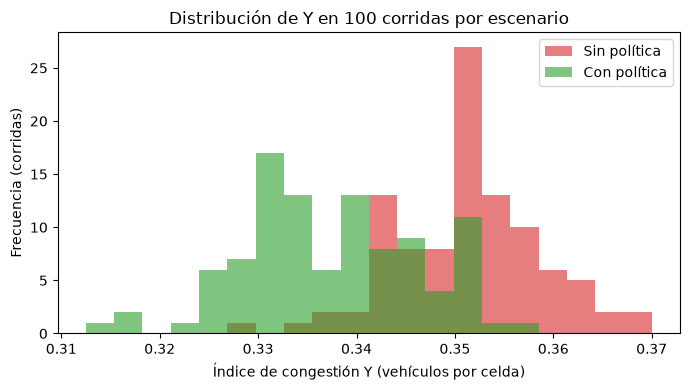

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.histogram_bin_edges(np.concatenate([Y_sin, Y_con]), bins=20)
ax.hist(Y_sin, bins=bins, alpha=0.6, color="tab:red", label="Sin política")
ax.hist(Y_con, bins=bins, alpha=0.6, color="tab:green", label="Con política")
ax.set_xlabel("Índice de congestión Y (vehículos por celda)")
ax.set_ylabel("Frecuencia (corridas)")
ax.set_title(f"Distribución de Y en {M} corridas por escenario")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
Z_95, ERROR_REL = 1.96, 0.05

print(f"{'escenario':<14}{'media':>10}{'desv':>10}{'CV':>10}{'M*':>8}")
resumen = {}
for nombre, Y in (("sin politica", Y_sin), ("con politica", Y_con)):
    media, desv = Y.mean(), Y.std(ddof=1)
    cv = desv / media
    m_min = int(np.ceil((Z_95 * cv / ERROR_REL) ** 2))   # M* = (z * CV / error)^2
    resumen[nombre] = (media, desv, cv, m_min)
    print(f"{nombre:<14}{media:>10.4f}{desv:>10.4f}{cv:>10.4f}{m_min:>8d}")

escenario          media      desv        CV      M*
sin politica      0.3513    0.0075    0.0214       1
con politica      0.3376    0.0090    0.0266       2


**Interpretación**

Sin política la congestión promedio final es de 0.351 vehículos por celda y con política baja a 0.338. La desviación entre corridas es muy pequeña (menos de 0.01), de modo que el coeficiente de variación queda en 2.1% y 2.7% (el modelo es poco ruidoso porque casi toda la variabilidad proviene del muestreo de atributos y de las posiciones iniciales).

Con esa variabilidad, la fórmula $M^{*} = (z\,CV/\varepsilon)^{2}$ con $z = 1.96$ y $\varepsilon = 0.05$ da $M^{*} = 1$ y $M^{*} = 2$ corridas. Las 100 corridas ejecutadas superan con buen margen el mínimo necesario para estimar la media con menos de 5% de error relativo.

## Task 2.2 — Bootstrap e intervalos de confianza

El bootstrap remuestrea con reemplazo las 100 corridas $B = 2000$ veces y calcula la media de cada remuestra. La dispersión de esas 2000 medias estima el error estándar, y sus percentiles 2.5 y 97.5 dan el intervalo de confianza del 95% sin suponer normalidad.

In [12]:
B = 2000


def bootstrap_medias(datos, B=2000, semilla=12345):
    """Devuelve las B medias remuestreadas con reemplazo."""
    rng = np.random.default_rng(semilla)
    indices = rng.integers(0, len(datos), size=(B, len(datos)))
    return datos[indices].mean(axis=1)


for nombre, Y in (("sin politica", Y_sin), ("con politica", Y_con)):
    medias = bootstrap_medias(Y, B)
    inferior, superior = np.percentile(medias, [2.5, 97.5])
    print(f"{nombre}: media_boot={medias.mean():.4f}  se_boot={medias.std(ddof=1):.5f}  "
          f"IC95=[{inferior:.4f}, {superior:.4f}]")

sin politica: media_boot=0.3513  se_boot=0.00076  IC95=[0.3498, 0.3528]
con politica: media_boot=0.3375  se_boot=0.00090  IC95=[0.3357, 0.3392]


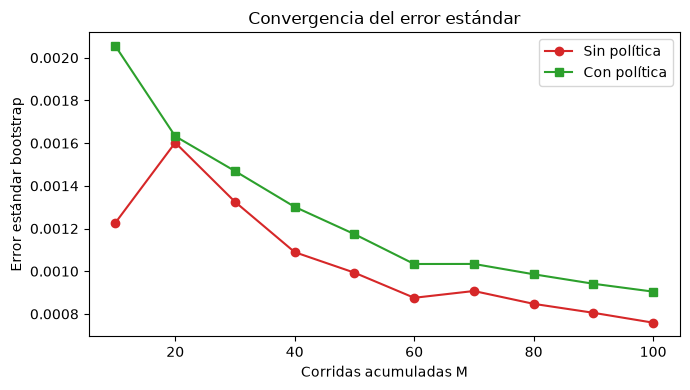

M= 10  se_sin=0.00123  se_con=0.00205
M= 20  se_sin=0.00160  se_con=0.00163
M= 30  se_sin=0.00133  se_con=0.00147
M= 40  se_sin=0.00109  se_con=0.00130
M= 50  se_sin=0.00099  se_con=0.00117
M= 60  se_sin=0.00088  se_con=0.00103
M= 70  se_sin=0.00091  se_con=0.00103
M= 80  se_sin=0.00085  se_con=0.00099
M= 90  se_sin=0.00081  se_con=0.00094
M=100  se_sin=0.00076  se_con=0.00090


In [13]:
tamanos = np.arange(10, M + 1, 10)
se_sin = [bootstrap_medias(Y_sin[:m], B).std(ddof=1) for m in tamanos]
se_con = [bootstrap_medias(Y_con[:m], B).std(ddof=1) for m in tamanos]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tamanos, se_sin, "o-", color="tab:red", label="Sin política")
ax.plot(tamanos, se_con, "s-", color="tab:green", label="Con política")
ax.set_xlabel("Corridas acumuladas M")
ax.set_ylabel("Error estándar bootstrap")
ax.set_title("Convergencia del error estándar")
ax.legend()
plt.tight_layout()
plt.show()

for m, a, b in zip(tamanos, se_sin, se_con):
    print(f"M={m:3d}  se_sin={a:.5f}  se_con={b:.5f}")

**Lectura de la curva:**

Con pocas corridas el error estándar es inestable: sube entre $M = 10$ y $M = 20$ y luego desciende de forma sostenida. A partir de $M \approx 60$ la curva se aplana; pasar de 60 a 100 corridas lo reduce de unos 0.0009 a 0.0008, un cambio irrelevante frente al tamaño del efecto que se quiere medir (0.0137). Cien corridas son suficientes para este modelo; agregar más solo repetiría la conclusión a mayor costo.

In [14]:
rng_dif = np.random.default_rng(2024)
idx_sin = rng_dif.integers(0, M, size=(B, M))
idx_con = rng_dif.integers(0, M, size=(B, M))
diferencias = Y_sin[idx_sin].mean(axis=1) - Y_con[idx_con].mean(axis=1)

delta = Y_sin.mean() - Y_con.mean()
inferior, superior = np.percentile(diferencias, [2.5, 97.5])

print(f"Delta Y = {delta:.4f} vehiculos por celda")
print(f"equivale a {delta * GRID * GRID:.1f} vehiculos menos en la cuadricula")
print(f"reduccion relativa = {100 * delta / Y_sin.mean():.1f} %")
print(f"IC95 bootstrap = [{inferior:.4f}, {superior:.4f}]")
print("el intervalo incluye el cero:", inferior <= 0 <= superior)

Delta Y = 0.0137 vehiculos por celda
equivale a 5.5 vehiculos menos en la cuadricula
reduccion relativa = 3.9 %
IC95 bootstrap = [0.0114, 0.0162]
el intervalo incluye el cero: False


**Interpretación**

La política reduce la congestión en 0.0137 vehículos por celda, con intervalo de confianza del 95% de [0.0114, 0.0162]. El intervalo **no incluye el cero** y está completamente del lado positivo, así que la reducción es estadísticamente significativa según el modelo.

La magnitud, sin embargo, es baja: unos 5.5 vehículos menos en las 400 celdas, cerca de 3.9% de la congestión del escenario sin política. La razón de este fenómeno es estructural, con una distancia media de 6.5 km y desviación de 2 km, apenas 4% de los conmutadores vive a 3 km o menos y puede cambiarse a la bicicleta. Para la Municipalidad esto significa que la política sí funciona en la dirección esperada y de forma consistente, pero que su efecto sobre la congestión total será pequeño mientras el umbral de 3 km deje fuera al 96% de la población que se desplaza.

### Recomendación Ejecutiva

Señor director de planificación urbana:

La simulación indica que el sistema de bicicletas compartidas sí reduce la congestión del centro. El efecto estimado equivale a unos cinco o seis automóviles menos circulando en el área analizada al final del período observado, cerca de un **cuatro por ciento** menos de congestión que sin la política.

El rango de confianza del **noventa y cinco por ciento** va de cinco a seis automóviles y no incluye el cero; es decir, la reducción es consistente en cien simulaciones y no producto del azar. La evidencia respalda avanzar con la política, entendiendo que el beneficio es real pero "modesto".

Una limitación importante del modelo es la suposición de que todas las personas que viven a tres kilómetros o menos de su trabajo adoptan la bicicleta, y ese grupo es apenas una fracción pequeña de quienes realmente se desplazan en la actualidad. Si la adopción real es menor o falta infraestructura ciclista segura, el beneficio será todavía más pequeño.